<a href="https://colab.research.google.com/github/Zidane86-06/Data_Engineering_workshop/blob/main/Day5/Day5%20mini%20project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd


In [2]:
df = pd.read_csv('/content/student_performance.csv')
display(df.head())

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [3]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   student_id             30 non-null     int64 
 1   name                   30 non-null     object
 2   age                    30 non-null     int64 
 3   gender                 30 non-null     object
 4   department             30 non-null     object
 5   semester               30 non-null     int64 
 6   math_score             30 non-null     int64 
 7   science_score          30 non-null     int64 
 8   english_score          30 non-null     int64 
 9   programming_score      30 non-null     int64 
 10  attendance_percentage  30 non-null     int64 
 11  city                   30 non-null     object
 12  admission_year         30 non-null     int64 
dtypes: int64(9), object(4)
memory usage: 3.2+ KB


None

In [4]:
display(df.describe())

,student_id,age,semester,math_score,science_score,english_score,programming_score,attendance_percentage,admission_year
count,30.000000,30.000000,30.0,30.000000,30.000000,30.000000,30.000000,30.000000,30.0
mean,1015.500000,19.733333,2.0,76.066667,77.833333,74.166667,67.600000,84.500000,2023.0
std,8.803408,0.739680,0.0,11.467896,8.554423,10.003735,21.041175,9.379913,0.0
min,1001.000000,19.000000,2.0,56.000000,61.000000,55.000000,38.000000,65.000000,2023.0
25%,1008.250000,19.000000,2.0,67.250000,71.250000,67.250000,49.250000,77.250000,2023.0
50%,1015.500000,20.000000,2.0,75.500000,78.000000,75.000000,66.000000,86.500000,2023.0
75%,1022.750000,20.000000,2.0,85.750000,83.750000,81.750000,88.750000,91.750000,2023.0
max,1030.000000,21.000000,2.0,95.000000,93.000000,90.000000,97.000000,98.000000,2023.0


In [5]:
import sqlite3
conn = sqlite3.connect(':memory:')
df.to_sql('students', conn, index=False, if_exists='replace')

print("DataFrame successfully stored in SQLite table 'students'.")

DataFrame successfully stored in SQLite table 'students'.


In [6]:
query1 = """
SELECT
    gender,
    AVG(math_score) AS avg_math_score,
    AVG(science_score) AS avg_science_score,
    AVG(english_score) AS avg_english_score,
    AVG(programming_score) AS avg_programming_score
FROM students
GROUP BY gender;
"""

result1 = pd.read_sql_query(query1, conn)
display(result1)

,gender,avg_math_score,avg_science_score,avg_english_score,avg_programming_score
0,Female,78.466667,81.200000,80.800000,70.2
1,Male,73.666667,74.466667,67.533333,65.0


In [7]:
query2 = """
SELECT
    department,
    AVG(math_score) AS avg_math_score,
    AVG(science_score) AS avg_science_score,
    AVG(english_score) AS avg_english_score,
    AVG(programming_score) AS avg_programming_score
FROM students
GROUP BY department
ORDER BY department;
"""

result2 = pd.read_sql_query(query2, conn)
display(result2)

,department,avg_math_score,avg_science_score,avg_english_score,avg_programming_score
0,Civil,63.400000,66.600000,65.200000,40.600000
1,Computer Science,85.615385,84.461538,80.846154,89.230769
2,Electronics,71.000000,74.166667,70.833333,61.500000
3,Mechanical,71.000000,76.500000,70.500000,49.333333


In [8]:
query3 = """
SELECT
    city,
    COUNT(student_id) AS number_of_students
FROM students
GROUP BY city
ORDER BY number_of_students DESC;
"""

result3 = pd.read_sql_query(query3, conn)
display(result3)

,city,number_of_students
0,Thiruvananthapuram,2
1,Lucknow,2
2,Kolkata,2
3,Kochi,2
4,Agra,2
5,Varanasi,1
6,Thrissur,1
7,Surat,1
8,Pune,1
9,Patna,1


In [9]:
query4 = """
SELECT
    name,
    department,
    (math_score + science_score + english_score + programming_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 5;
"""

result4 = pd.read_sql_query(query4, conn)
display(result4)

,name,department,total_score
0,Ananya Das,Computer Science,371
1,Tanvi Mehta,Computer Science,367
2,Akanksha Yadav,Computer Science,365
3,Arjun Nair,Computer Science,356
4,Divya Singh,Computer Science,356


In [10]:
query5 = """
SELECT
    name,
    department,
    attendance_percentage
FROM students
WHERE attendance_percentage < 80
ORDER BY attendance_percentage ASC;
"""

result5 = pd.read_sql_query(query5, conn)
display(result5)

,name,department,attendance_percentage
0,Manoj Pandey,Civil,65
1,Rahul Mishra,Mechanical,68
2,Sanjay Dubey,Civil,70
3,Meera Joshi,Electronics,72
4,Sunita Pillai,Civil,73
5,Harish Pillai,Electronics,74
6,Ajay Tiwari,Computer Science,75
7,Deepak Chauhan,Mechanical,77
8,Rohit Verma,Electronics,78


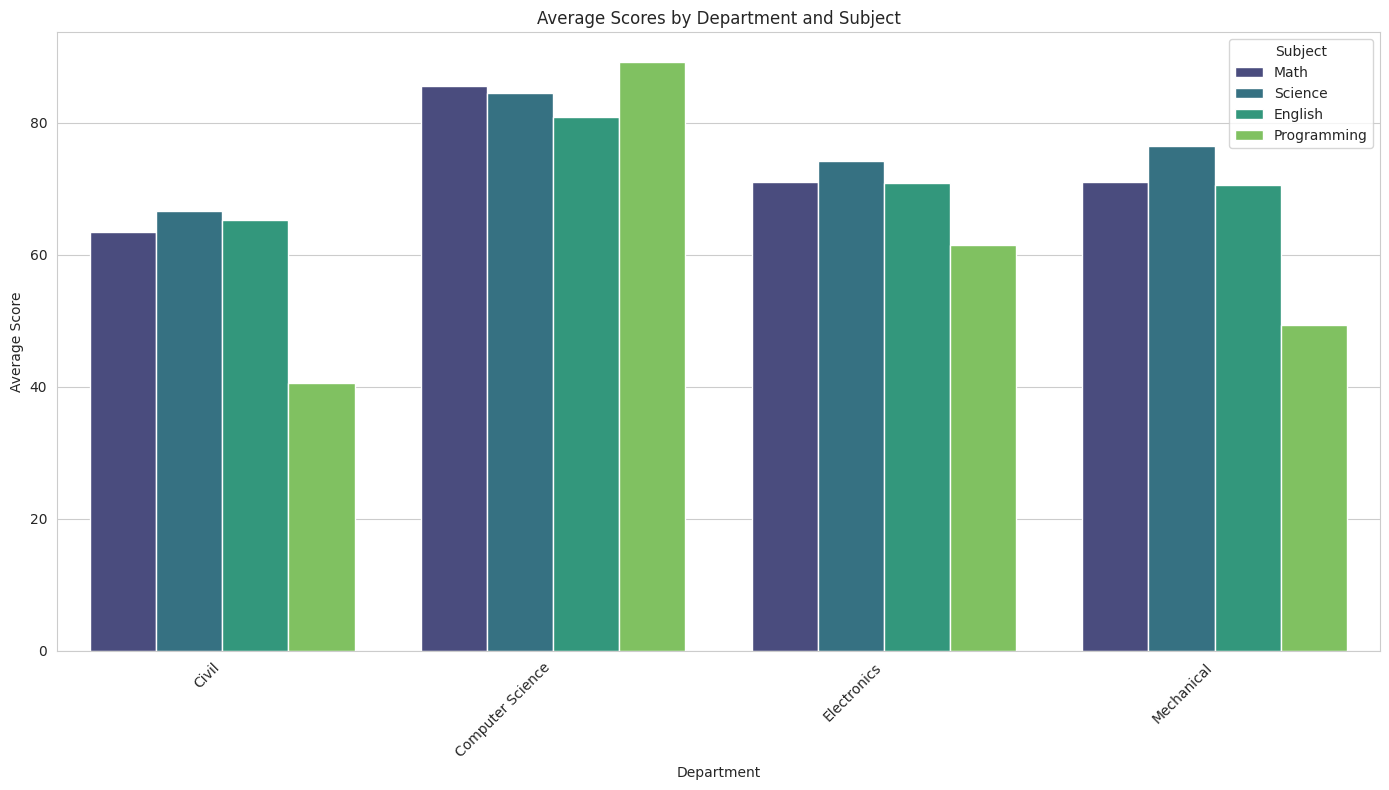

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.figure(figsize=(14, 8))
result2_melted = result2.melt(id_vars='department', var_name='Score Type', value_name='Average Score')
result2_melted['Score Type'] = result2_melted['Score Type'].str.replace('avg_', '').str.replace('_score', '').str.capitalize()
sns.barplot(x='department', y='Average Score', hue='Score Type', data=result2_melted, palette='viridis')
plt.title('Average Scores by Department and Subject')
plt.xlabel('Department')
plt.ylabel('Average Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Subject')
plt.tight_layout()
plt.show()

/tmp/ipykernel_4312/591015963.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='name', y='attendance_percentage', data=result5, palette='plasma')


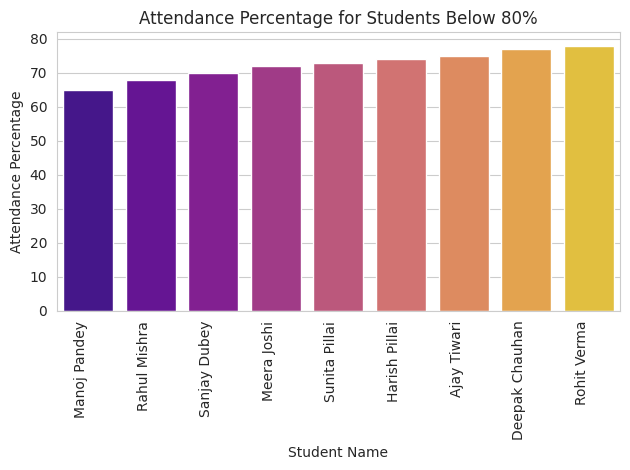

In [12]:
sns.barplot(x='name', y='attendance_percentage', data=result5, palette='plasma')
plt.title('Attendance Percentage for Students Below 80%')
plt.xlabel('Student Name')
plt.ylabel('Attendance Percentage')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_4312/612837615.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Subject', y='Score', data=df_scores_melted, palette='coolwarm')


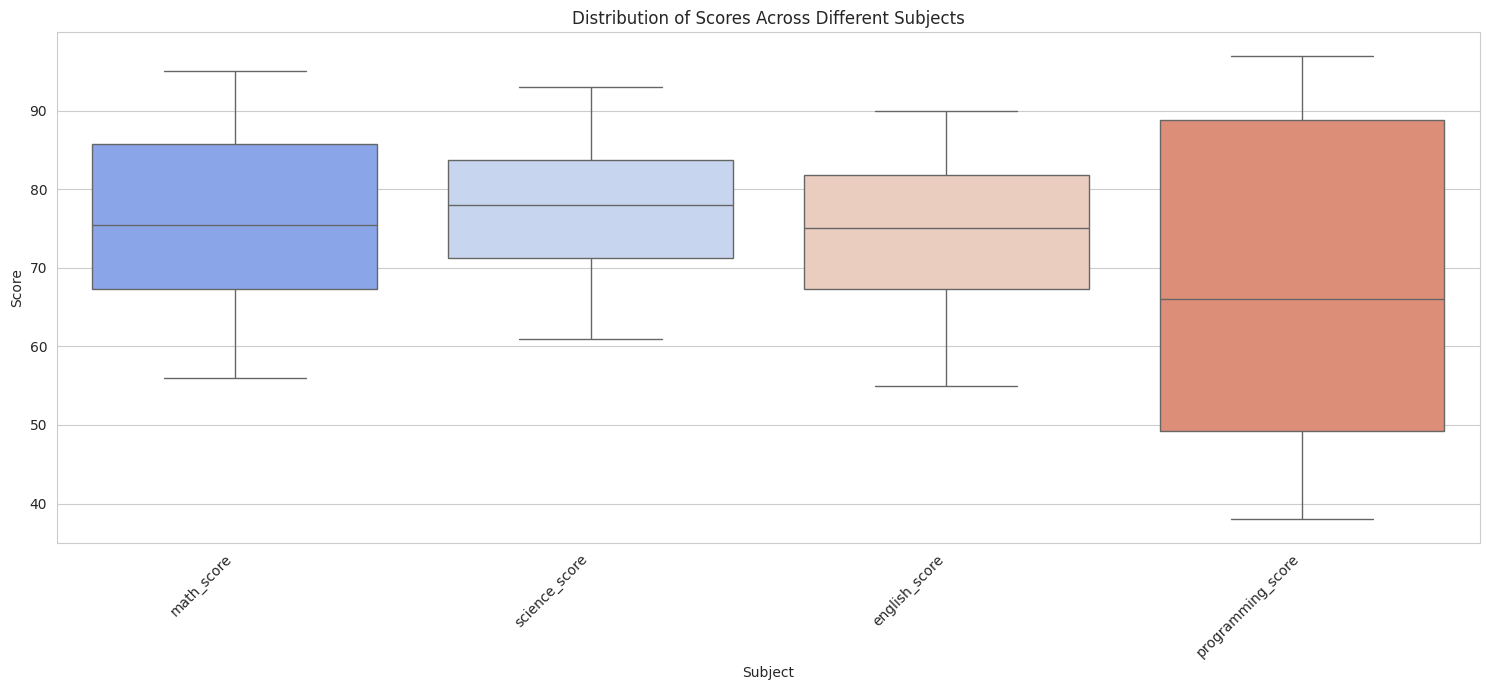

In [13]:
plt.figure(figsize=(15, 7))
score_columns = ['math_score', 'science_score', 'english_score', 'programming_score']
df_scores_melted = df[score_columns].melt(var_name='Subject', value_name='Score')

sns.boxplot(x='Subject', y='Score', data=df_scores_melted, palette='coolwarm')
plt.title('Distribution of Scores Across Different Subjects')
plt.xlabel('Subject')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
from sklearn.model_selection import train_test_split

X = df[['age', 'semester', 'math_score', 'science_score', 'english_score', 'attendance_percentage']]
y = df['programming_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (24, 6)
X_test shape: (6, 6)
y_train shape: (24,)
y_test shape: (6,)


In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = RandomForestRegressor(n_estimators=100, random_state=42)


model.fit(X_train, y_train)


y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 11.70
Mean Squared Error (MSE): 212.57
R-squared (R2): 0.57


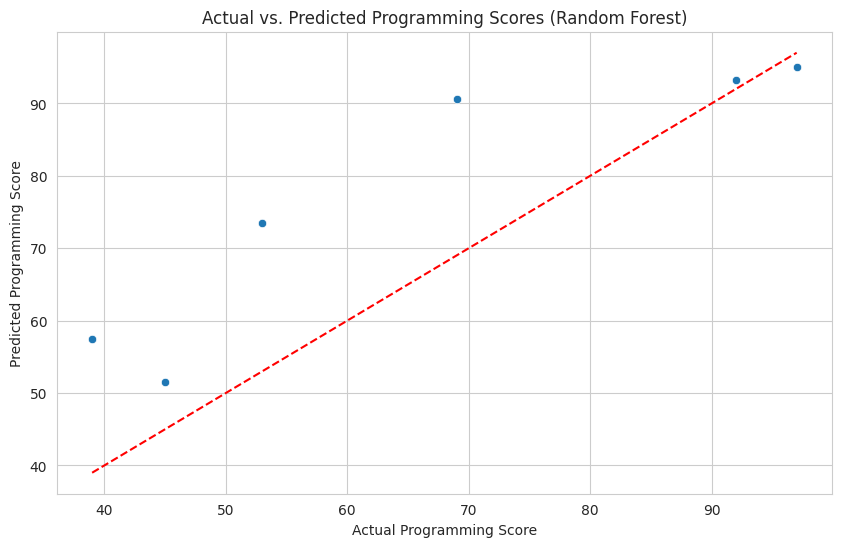

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Programming Score')
plt.ylabel('Predicted Programming Score')
plt.title('Actual vs. Predicted Programming Scores (Random Forest)')
plt.grid(True)
plt.show()

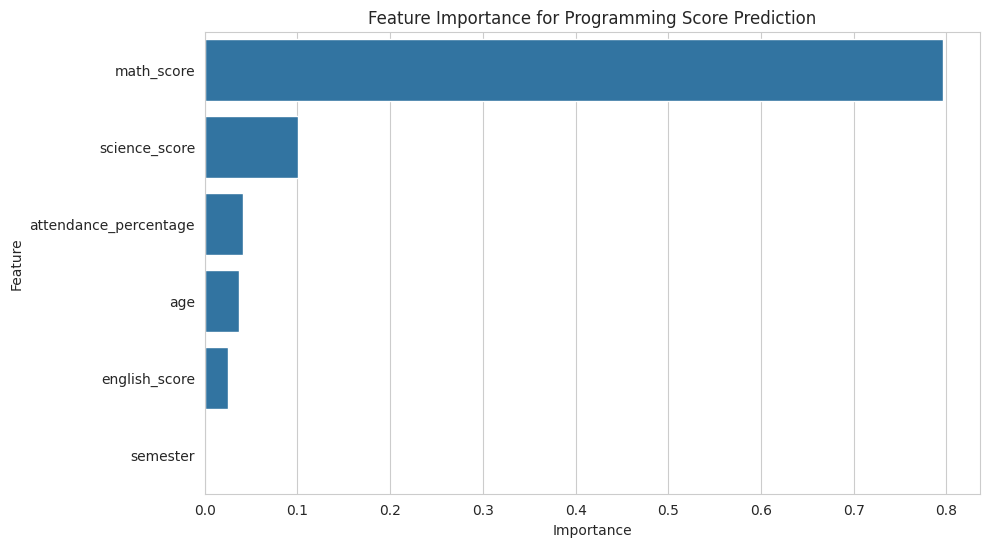

In [17]:
feature_importances = pd.DataFrame({'feature': X.columns, 'importance': model.feature_importances_})
feature_importances = feature_importances.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importances)
plt.title('Feature Importance for Programming Score Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()